# Linear Regression — Implementation and Evaluation

**Dataset:** Diabetes (scikit-learn built-in)  
**Goal:** Train a simple linear regression model using BMI as the single feature and evaluate it using MAE, MSE, RMSE, and R² score.

**Prerequisites:**
- Basic Python and pandas knowledge
- Understanding of what regression means — predicting a continuous number, not a category
- No prior ML experience needed — everything is explained as we go

**Pipeline overview:**
1. Imports
2. Load the dataset
3. Select feature (X) and target (y)
4. Split into training and testing sets
5. Create and train the model
6. Inspect the learned coefficient (slope)
7. Inspect the learned intercept
8. Predict on the test set
9. Evaluate — MAE, MSE, RMSE, R²
10. Visualize — regression line and actual vs predicted

## Step 1 — Imports

**What:** Imports three tools from scikit-learn:
- `load_diabetes` — loads a built-in sample dataset
- `LinearRegression` — the model we will train
- `train_test_split` — splits data into training and testing portions

**Why:** These are needed before anything else — you always import the tools at the top of a notebook before using them below.

**Watch out:** Import order does not matter to Python, but by convention keep all imports at the top so anyone reading the notebook knows exactly what is needed upfront.

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Step 2 — Load the Dataset

**What:**
- `load_diabetes(as_frame=True)` loads scikit-learn's built-in diabetes dataset and returns the data as pandas objects instead of plain NumPy arrays.
- The result `data` is a Bunch — a container object that bundles several related pieces: `data.data` (features only), `data.target` (target only), `data.frame` (features + target combined), `data.feature_names`, `data.DESCR`.
- `df = data.frame` pulls out the combined table (10 features + target column, 11 columns total).

**Why:** `as_frame=True` attaches proper column names (`age`, `sex`, `bmi`, `bp`, `s1`...`s6`, `target`) to the data, which is needed for DataFrame-style column selection used later.

**Watch out:** Without `as_frame=True`, the data comes back as a plain NumPy array with no column names — you would have to track columns by index number instead.

**Output:** A 442-row × 11-column DataFrame — every patient's 10 features plus their target value (a measure of disease progression one year after baseline).

In [2]:
data = load_diabetes(as_frame=True)
df = data.frame
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## Step 3 — Select Feature (X) and Target (y)

**What:**
- `df[['bmi']]` selects just the bmi column, keeping it as a DataFrame (double brackets), not a Series.
- `df[['target']]` does the same for the target column.

**Why:** Only one feature (bmi) is used deliberately so the relationship between input and output can be visualised as a simple 2D line. X becomes the model's input, y becomes what it is trying to predict.

**Watch out:** Single brackets `df['bmi']` would give a 1D Series — scikit-learn's model expects a 2D input shape even for a single feature. Double brackets keep it as a DataFrame with shape (442, 1).

**Result:**
- X → shape (442, 1)
- y → shape (442, 1)

In [3]:
X = df[['bmi']]
y = df[['target']]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (442, 1)
y shape: (442, 1)


## Step 4 — Split into Training and Testing Sets

**What:** `train_test_split` takes X and y and splits both into a training portion and a testing portion, keeping each row's feature correctly matched with its target.
- `test_size=0.2` → 20% of rows (89 rows) go to testing, 80% (353 rows) go to training
- `random_state=26` → fixes the random shuffle so re-running gives the exact same split every time

**Why:** The model must be trained on one set of rows and evaluated on a different set it never saw. This is how you tell if a model has learned the general pattern (generalises well) versus just memorised the training data (overfitting).

**Watch out:** `train_test_split` always returns outputs in this fixed order — features-train, features-test, target-train, target-test. Getting the order wrong on the left side would silently mislabel your data — Python will not catch that mistake.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (353, 1)
X_test shape:  (89, 1)
y_train shape: (353, 1)
y_test shape:  (89, 1)


## Step 5 — Create and Train the Model

**What:**
- `LinearRegression()` creates a fresh, untrained model object.
- `.fit(X_train, y_train)` trains it — this is where the model finds the best-fit line using only the 353 training rows.

**Why:** `fit()` runs the optimisation — it finds the slope (coefficient) and intercept that minimise the prediction error on the training data. This is the actual learning step.

**Watch out:** Never pass X_test or y_test to `fit()`. The model must not see test data during training — that would be data leakage and would give falsely optimistic evaluation results.

**Output — two kinds of attributes:**
- **Parameters** (set before training): `fit_intercept`, `copy_X`, etc. — configuration, not learned
- **Fitted attributes** (only exist after `fit()` runs): `coef_` and `intercept_` — the actual learned slope and intercept

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model trained successfully")

Model trained successfully


## Step 6 — Inspect the Learned Coefficient (Slope)

**What:** `model.coef_` returns the learned slope (m in y = mx + c) as a 2D array since the input X had one column.

**Why:** The coefficient tells you the relationship between the feature and the target. A positive value means they move in the same direction — higher BMI predicts higher disease progression.

**Watch out:** The BMI values in this dataset are already standardised (scaled to have mean 0 and std 1), so the coefficient is not in the original BMI units — it represents the change in target per one standard deviation change in BMI.

**Interpreting the output:** `coef_ ≈ [[978.21]]` means for every 1-unit increase in the scaled BMI value, the predicted target increases by about 978.21.

In [6]:
print(f"Coefficient (slope): {model.coef_}")

Coefficient (slope): [[978.20701858]]


## Step 7 — Inspect the Learned Intercept

**What:** `model.intercept_` returns the learned intercept (c in y = mx + c) — the predicted target when BMI = 0.

**Why:** The intercept anchors the line. Combined with the coefficient, it gives the full equation of the fitted line.

**Interpreting the output:** `intercept_ ≈ [151.86]`. Combined with the coefficient, the fitted line is:

`predicted target = 978.21 × bmi + 151.86`

**Watch out:** The intercept has a physical meaning only in the context of the scaled data. Since BMI = 0 after standardisation means BMI is at its mean value, the intercept represents the predicted target for an average-BMI patient.

In [7]:
print(f"Intercept: {model.intercept_}")

Intercept: [151.86167557]


## Step 8 — Predict on the Test Set

**What:** Plugs each of the 89 BMI values in X_test into the learned equation, producing 89 predictions. No new learning happens here — it is pure arithmetic using the already-fitted line.

**Why:** We run the model on data it has never seen to get predictions we can compare against the real y_test values. This is the evaluation step.

**Watch out:** Some predictions may repeat exactly — because this model uses a single straight line and only one feature, any two patients with the same BMI will always get the identical prediction even if their true outcomes differ. This is a sign of underfitting when using only one feature.

**Output:** A NumPy array of shape (89, 1) — one predicted target value per test row.

In [8]:
y_pred = model.predict(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"First 5 predictions: {y_pred[:5].flatten().round(2)}")
print(f"First 5 actual:      {y_test.values[:5].flatten()}")

Predictions shape: (89, 1)
First 5 predictions: [134.19 189.02 184.8  162.66 126.81]
First 5 actual:      [ 77. 167. 198. 111. 118.]


## Step 9 — Evaluate the Model

**What:** Four metrics that each measure a different aspect of prediction quality.

**Why:** A single number never tells the full story. Each metric has a different sensitivity to errors — understanding all four gives a complete picture.

| Metric | What it measures | Units |
|---|---|---|
| MAE | Average absolute error — easy to interpret | Same as target |
| MSE | Average squared error — penalises large mistakes more | Squared target units |
| RMSE | Square root of MSE — brings it back to target units | Same as target |
| R² | How much variance the model explains (0 to 1) | Unitless |

**Watch out:**
- MSE is in squared units — hard to interpret directly, use RMSE for interpretability
- R² of 1.0 means perfect prediction, 0 means the model is no better than predicting the mean every time, negative means worse than predicting the mean
- All metrics are calculated on the **test set**, not the training set — training metrics would be overly optimistic

In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  51.5382
MSE:  3863.7719
RMSE: 62.1592
R²:   0.2250


## Step 10 — Visualise

**Two plots:**

**Plot 1 — Scatter with regression line:** Shows the raw data points (BMI vs target) with the fitted line drawn over them. Gives a visual sense of how well the line fits the data.

**Plot 2 — Actual vs Predicted:** Each point is one test patient — x-axis is the real target value, y-axis is the predicted value. A perfect model would put all points on the diagonal line. Points scattered away from the diagonal show where the model is making mistakes.

**Watch out:** Both plots use only the test set — never mix training and test data when evaluating.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


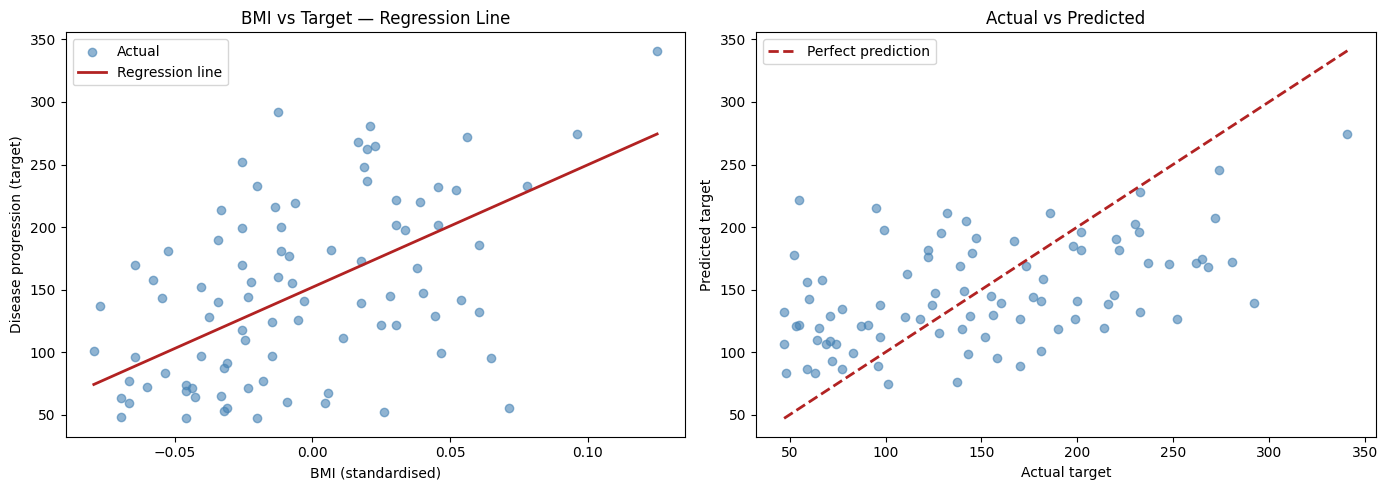

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Scatter with regression line
axes[0].scatter(X_test, y_test, color='steelblue', alpha=0.6, label='Actual')
X_line = np.linspace(X_test.values.min(), X_test.values.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
axes[0].plot(X_line, y_line, color='firebrick', linewidth=2, label='Regression line')
axes[0].set_xlabel('BMI (standardised)')
axes[0].set_ylabel('Disease progression (target)')
axes[0].set_title('BMI vs Target — Regression Line')
axes[0].legend()

# Plot 2 — Actual vs Predicted
axes[1].scatter(y_test, y_pred, color='steelblue', alpha=0.6)
min_val = min(y_test.values.min(), y_pred.min())
max_val = max(y_test.values.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='firebrick', linewidth=2, linestyle='--', label='Perfect prediction')
axes[1].set_xlabel('Actual target')
axes[1].set_ylabel('Predicted target')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()